In [66]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [67]:
# Load the final product
df = pd.read_csv('../data/processed/engineered_features.csv')

print("--- FINAL DATA CHECK ---")
print(f"Total Entries: {len(df)}")
print(f"Column Count: {len(df.columns)}")
#curr is 194

--- FINAL DATA CHECK ---
Total Entries: 1989
Column Count: 104


In [68]:
print("\n--- COLUMN OVERVIEW ---")
print(df.columns.tolist())

print("\n--- DTYPES ---")
print(df.dtypes.value_counts())

print("\n--- SAMPLE ---")
display(df.head())


--- COLUMN OVERVIEW ---
['Player', 'Age', 'Team', 'Position', 'Games Played', 'Fenwick For', 'Fenwick Against', 'Fenwick For Pct', 'Fenwick For Pct Relative', 'On Ice Shooting Pct', 'On Ice Save Pct', 'Player Development Index', 'Ozone Start Pct', 'TOI Per 60', 'Shot Attempts', 'Shots Through %', 'Short Handed Goals', 'Game Winning Goals', 'Even Strength points', 'PP points', 'SH points', 'Shooting Pct', 'Total Ice Time', 'Avg TOI', 'Faceoff Pct', 'Blocks', 'Hits', 'Power Play Time On Ice', 'Short Handed Time On Ice', 'Season', 'Player ID', 'Situation', 'Shifts', 'Game Score', 'On Ice Fenwick Pct_MP', 'Individual Shot Attempts_MP', 'Points_MP', 'Goals_MP', 'Individual Rebounds_MP', 'Individual Rebound Goals_MP', 'Individual Freeze_MP', 'Individual Play Stopped_MP', 'Penalties Taken_MP', 'lowDangerxGoals', 'mediumDangerxGoals', 'lowDangerGoals', 'mediumDangerGoals', 'highDangerGoals', 'Individual OZone Shift Starts_MP', 'Individual DZone Shift Starts_MP', 'Individual OZone Shift Ends_M

,Player,Age,Team,Position,Games Played,Fenwick For,Fenwick Against,Fenwick For Pct,Fenwick For Pct Relative,On Ice Shooting Pct,...,Goals_minus_xGoals,Shooting_Pct,Shooting_Pct_valid,highDanger_Conversion,Points_per_60_alt,CapHit_per_Point,CapHit_per_xG,CapHit_per_TOI,Points_per_CapPct,xG_per_CapPct
0,A.J. Greer,21,COL,LW,17,66,99,40.0,-3.8,7.7,...,-0.37,NaN,0,1.250000,1.432171,0.247222,0.541363,0.005901,3.215729,1.468516
1,Aaron Ness,29,ARI,D,24,199,207,49.0,1.3,8.8,...,-0.07,NaN,0,0.000000,0.199446,0.725000,10.357143,0.002410,1.124138,0.078690
2,Adam Boqvist,19,CHI,D,41,419,458,47.8,1.1,9.2,...,1.03,0.102564,1,0.746269,1.172727,0.068782,0.301066,0.001344,11.849017,2.707045
3,Adam Edstrom,23,NYR,C,11,36,81,30.8,-16.2,12.0,...,-5.11,0.050000,1,0.317460,1.297064,0.423333,0.119081,0.009152,2.078739,7.389918
4,Adam Erne,22,TBL,LW,23,155,130,54.4,3.7,8.0,...,-4.49,0.042857,1,1.104972,1.031223,0.200000,0.106809,0.003437,3.975000,7.443187


In [69]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

print("\n--- MISSING VALUES ---")
print(f"Columns with missing values: {len(missing)}")

if len(missing) > 0:
    display(
        pd.DataFrame({
            "Missing Count": missing,
            "Missing %": (missing / len(df) * 100).round(2)
        })
    )
else:
    print("No missing values found.")


--- MISSING VALUES ---
Columns with missing values: 1


,Missing Count,Missing %
Shooting_Pct,82,4.12


In [70]:
print("\n--- DUPLICATE CHECK ---")
dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {dupes}")

key_cols = ["Player", "Season", "Team"] if all(c in df.columns for c in ["Player", "Season", "Team"]) else None

if key_cols:
    key_dupes = df.duplicated(subset=key_cols).sum()
    print(f"Duplicate Player-Season-Team rows: {key_dupes}")


--- DUPLICATE CHECK ---
Exact duplicate rows: 0
Duplicate Player-Season-Team rows: 0


In [71]:
num_df = df.select_dtypes(include=["number"])

print("\n--- NUMERIC SUMMARY ---")
display(num_df.describe().T)


--- NUMERIC SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
Age,1989.0,26.184012,4.078743,18.000000,23.000000,26.000000,29.000000,39.000000
Games Played,1989.0,62.866264,18.831542,10.000000,53.000000,69.000000,79.000000,82.000000
Fenwick For,1989.0,681.264454,288.121046,36.000000,481.000000,698.000000,888.000000,1416.000000
Fenwick Against,1989.0,656.268477,263.952884,45.000000,478.000000,669.000000,848.000000,1374.000000
Fenwick For Pct,1989.0,50.589844,4.072716,30.800000,48.000000,50.700000,53.200000,66.700000
...,...,...,...,...,...,...,...,...
CapHit_per_Point,1989.0,0.151298,0.142117,0.010157,0.075988,0.113636,0.178541,1.515000
CapHit_per_xG,1989.0,0.742166,2.358467,0.000000,0.173445,0.303514,0.676101,43.166700
CapHit_per_TOI,1989.0,0.003638,0.002701,0.000427,0.001845,0.003247,0.004754,0.046368
Points_per_CapPct,1989.0,9.792994,9.308308,0.562069,4.618333,7.285091,10.866667,78.272231


In [72]:
print("\n--- LOW VARIANCE CHECK ---")

nunique = num_df.nunique().sort_values()
low_var = nunique[nunique <= 1]
near_constant = nunique[nunique <= 3]

print(f"Constant numeric columns: {len(low_var)}")
if len(low_var) > 0:
    print(low_var)

print(f"\nNear-constant numeric columns (<=3 unique values): {len(near_constant)}")
display(near_constant)


--- LOW VARIANCE CHECK ---
Constant numeric columns: 0

Near-constant numeric columns (<=3 unique values): 1


Shooting_Pct_valid    2
dtype: int64

In [73]:
print("\n--- INFINITE VALUE CHECK ---")

inf_counts = pd.Series(
    np.isinf(num_df).sum(),
    index=num_df.columns
).sort_values(ascending=False)

inf_counts = inf_counts[inf_counts > 0]

if len(inf_counts) > 0:
    display(inf_counts)
else:
    print("No infinite values found.")


--- INFINITE VALUE CHECK ---
No infinite values found.


In [74]:
dist_summary = pd.DataFrame({
    "mean": num_df.mean(),
    "std": num_df.std(),
    "min": num_df.min(),
    "q1": num_df.quantile(0.25),
    "median": num_df.median(),
    "q3": num_df.quantile(0.75),
    "max": num_df.max(),
    "skew": num_df.skew()
})

# sort by absolute skew (largest first)
dist_summary = dist_summary.reindex(
    dist_summary["skew"].abs().sort_values(ascending=False).index
)

print("\n--- MOST SKEWED FEATURES ---")
display(dist_summary.head(25))


--- MOST SKEWED FEATURES ---


,mean,std,min,q1,median,q3,max,skew
CapHit_per_xG,0.742166,2.358467,0.000000,0.173445,0.303514,0.676101,43.166700,12.770970
Hits_per_60,5.580218,7.963075,0.000000,1.991728,3.586830,6.564588,143.601108,7.782821
Individual Hits_MP_pg,1.436203,1.600901,0.000000,0.609375,1.064935,1.800000,30.400000,7.458808
Blocks_per_60,3.386928,3.621622,0.000000,1.463273,2.434077,4.095410,53.740836,4.813100
Shooting_Pct_valid,0.958773,0.198864,0.000000,1.000000,1.000000,1.000000,1.000000,-4.618578
Shots Blocked By Player_MP_pg,0.987298,1.019171,0.000000,0.402439,0.670732,1.297872,15.363636,4.357092
Shots_on_Goal_per_60,7.680408,6.045199,0.000000,4.390098,6.428103,9.195675,80.802292,4.312322
CapHit_per_TOI,0.003638,0.002701,0.000427,0.001845,0.003247,0.004754,0.046368,4.260200
Shooting_Pct,0.104520,0.084786,0.000000,0.051058,0.088235,0.136869,1.269231,4.250281
CapHit_per_Point,0.151298,0.142117,0.010157,0.075988,0.113636,0.178541,1.515000,3.659703


In [75]:
corr_matrix = num_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0": "Feature_1",
             "level_1": "Feature_2",
             0: "Correlation"
         })
         .sort_values("Correlation", ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"] >= 0.85]

print("\n--- HIGH CORRELATION PAIRS (>= 0.85) ---")
display(high_corr_pairs)


--- HIGH CORRELATION PAIRS (>= 0.85) ---


,Feature_1,Feature_2,Correlation
4594,Points_per_60,Points_per_60_alt,1.000000
4532,FO_total_pg,Faceoff Impact_pg,0.994125
4163,Individual Shots On Goal_MP_pg,Individual xRebounds_MP_pg,0.971232
4055,Individual xGoals_MP_pg,mediumDangerShots_pg,0.958481
2414,Individual Shot Attempts_MP,lowDangerxGoals,0.957454
3625,On Ice Against xGoals_MP,On Ice Goals Against_MP,0.954317
4386,Individual Hits_MP_pg,Hits_per_60,0.949343
2270,Game Score,Points_MP,0.949199
4485,Shots Blocked By Player_MP_pg,Blocks_per_60,0.946847
3871,Goals_pg,Goals_per_60,0.941806


In [76]:
high_corr_pairs.head(25)

,Feature_1,Feature_2,Correlation
4594,Points_per_60,Points_per_60_alt,1.000000
4532,FO_total_pg,Faceoff Impact_pg,0.994125
4163,Individual Shots On Goal_MP_pg,Individual xRebounds_MP_pg,0.971232
4055,Individual xGoals_MP_pg,mediumDangerShots_pg,0.958481
2414,Individual Shot Attempts_MP,lowDangerxGoals,0.957454
3625,On Ice Against xGoals_MP,On Ice Goals Against_MP,0.954317
4386,Individual Hits_MP_pg,Hits_per_60,0.949343
2270,Game Score,Points_MP,0.949199
4485,Shots Blocked By Player_MP_pg,Blocks_per_60,0.946847
3871,Goals_pg,Goals_per_60,0.941806


In [77]:
INITIAL_DROP = [
    "Points_per_60_alt",        # exact duplicate
    "Points_pg",                # redundant vs per_60
    "Goals_pg",
    "Assists_pg",
    "FO_total_pg",              # redundant vs Faceoff Impact
    "Individual Hits_MP_pg",    # redundant vs Hits_per_60
    "Shots Blocked By Player_MP_pg",  # redundant vs Blocks_per_60
    "On Ice Goals Against_MP",  # worse version of xG against
    "Fenwick For",
    "Fenwick Against"
]

In [78]:
df_reduced = df.drop(columns=[c for c in INITIAL_DROP if c in df.columns])

print("Original columns:", len(df.columns))
print("After initial drop:", len(df_reduced.columns))

Original columns: 104
After initial drop: 94


In [79]:
num_df_reduced = df_reduced.select_dtypes(include=["number"])

corr_matrix = num_df_reduced.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0": "Feature_1",
             "level_1": "Feature_2",
             0: "Correlation"
         })
         .sort_values("Correlation", ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"] >= 0.85]

display(high_corr_pairs.head(25))

,Feature_1,Feature_2,Correlation
3368,Individual Shots On Goal_MP_pg,Individual xRebounds_MP_pg,0.971232
3272,Individual xGoals_MP_pg,mediumDangerShots_pg,0.958481
2005,Individual Shot Attempts_MP,lowDangerxGoals,0.957454
1877,Game Score,Points_MP,0.949199
3274,Individual xGoals_MP_pg,highDangerxGoals_pg,0.939858
3366,Individual Shots On Goal_MP_pg,lowDangerShots_pg,0.938333
3284,Individual xGoals_MP_pg,xGoals_per_60,0.935519
3275,Individual xGoals_MP_pg,Individual xRebounds_MP_pg,0.927022
3397,Individual Missed Shots_MP_pg,Individual xRebounds_MP_pg,0.926252
3461,mediumDangerShots_pg,xGoals_per_60,0.924206


In [80]:
SECOND_DROP = [
    "Individual Shots On Goal_MP_pg",
    "Individual Missed Shots_MP_pg",
    "lowDangerShots_pg",
    "mediumDangerShots_pg",
    "Individual xRebounds_MP_pg",
    "Individual xGoals_MP_pg",
    "Points_MP",
    "On Ice Rebounds For_MP",
    "On Ice Rebounds Against_MP",
    "lowDangerxGoals",
    "Goals_MP",
    "mediumDangerGoals",
    "Shifts"
]

df_reduced_2 = df_reduced.drop(
    columns=[c for c in SECOND_DROP if c in df_reduced.columns]
)

print("After second drop:", len(df_reduced_2.columns))

After second drop: 81


In [81]:
num_df_reduced_2 = df_reduced_2.select_dtypes(include=["number"])

corr_matrix = num_df_reduced_2.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs_2 = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0": "Feature_1",
             "level_1": "Feature_2",
             0: "Correlation"
         })
         .sort_values("Correlation", ascending=False)
)

high_corr_pairs_2 = high_corr_pairs_2[
    high_corr_pairs_2["Correlation"] >= 0.80
]

display(high_corr_pairs_2.head(20))

,Feature_1,Feature_2,Correlation
1612,Individual Shot Attempts_MP,On Ice For xGoals_MP,0.900013
1587,On Ice Fenwick Pct_MP,On Ice xGoals Ratio_MP,0.898022
1601,Individual Shot Attempts_MP,Individual Freeze_MP,0.896614
1999,Individual OZone Shift Starts_MP,On Ice For xGoals_MP,0.892488
1501,Game Score,Individual Shot Attempts_MP,0.885749
2639,Shots_on_Goal_per_60,xGoals_per_60,0.885048
2697,On Ice xGoals Diff_MP,On Ice xGoals Ratio_MP,0.880853
1515,Game Score,On Ice For xGoals_MP,0.876603
1510,Game Score,Individual OZone Shift Starts_MP,0.859859
2483,highDangerxGoals_pg,xGoals_per_60,0.858800


In [82]:
FINAL_DROP = [
    "On Ice Fenwick Pct_MP",
    "Individual Freeze_MP",
    "Assists_pg",
    "Goals_pg",
    "Points_pg",
    "Even Strength Goals_pg",
    "Individual DZone Giveaways_MP_pg",
    "Fenwick For",
    "Fenwick Against",
    "Fenwick For Pct",
    "Fenwick For Pct Relative"
]

df_reduced_final = df_reduced_2.drop(
    columns=[c for c in FINAL_DROP if c in df_reduced_2.columns]
)

print("After final drop:", len(df_reduced_final.columns))

After final drop: 75


In [83]:
corr_matrix = df_reduced_final.corr(numeric_only=True)

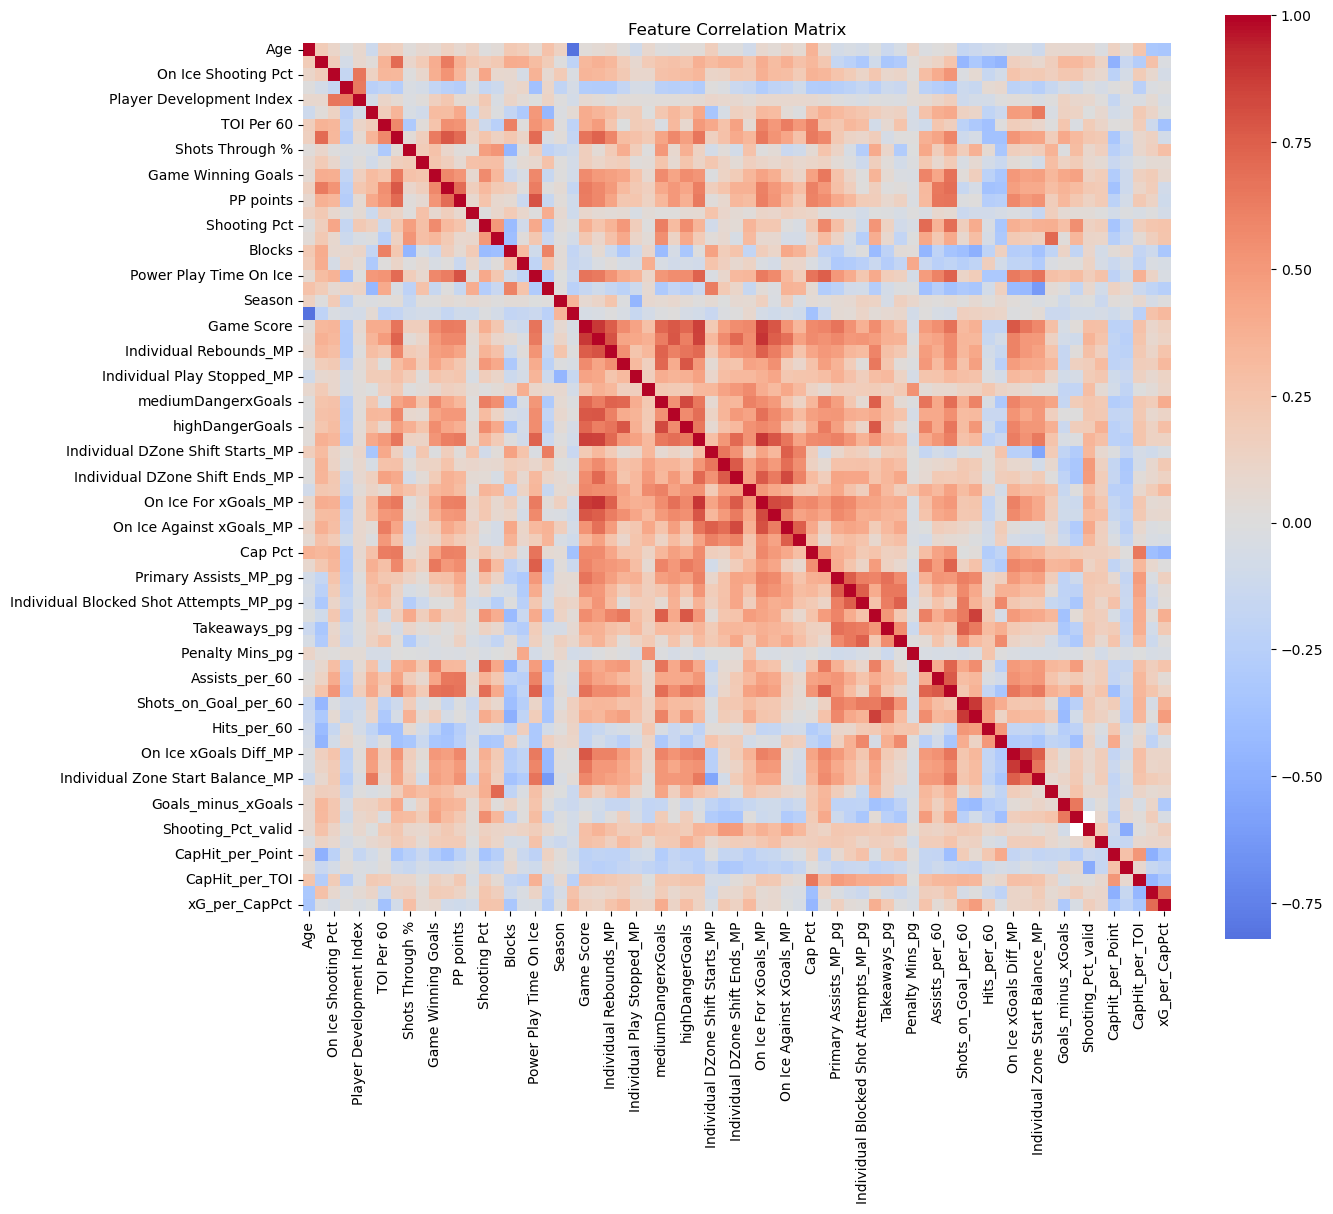

In [84]:
plt.figure(figsize=(14,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Feature Correlation Matrix")
plt.show()